In [1]:
#import req libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

import os
import warnings
warnings.filterwarnings("ignore")

os.environ["OMP_NUM_THREADS"] = "1"

# Smart Link EDA

In [2]:
df = pd.read_csv("sl_customer.csv")

In [3]:
df.head()

,merchant_id,consumer_id,consumer_status,partner_identifier_for_consumer,consumer_modified_date,consumer_member_token,account_id,account_status,account_modified_date,partner_identifier_for_account,offer_link_id,consumer_transacion_id,offer_link_status,offer_link_modified_date,settlement_amount,store_id,transaction_amount,transaction_date,transaction_campaign_id,offer_category_id
0,193,1906381155455937,Active,c0a8f2d30002b1d44c265c2a351d4000,2021-12-26 00:00:00.000000,5_d61db94e-7b02-46ae-b509-61b12b0cc6ff,1921381155455902,Active,2021-12-26 00:00:00.000000,A1fecc07c4d233552b11ac665a445863c,6607381154633510,25083821372301367,Settled,2022-01-13 00:00:00.000000,1.66,71186,27.66,2022-01-10 00:00:00.000000,9205751003553335297,8.0
1,193,22769394246314562,Active,234742,2023-08-19 00:00:00.000000,5_19554681-d6c5-4580-8158-b7543040e884,20088394246439967,Active,2023-08-19 00:00:00.000000,157448,96183942000496523,196993942000495389,Settled,2023-09-09 00:00:00.000000,0.55,80397,110.87,2023-09-05 00:00:00.000000,9205751003553336142,5.0
2,193,23038391143094108,Active,68143,2023-09-07 00:00:00.000000,1_a76f62e2-fb07-4ff8-8ba1-9fe6a5b39b54,23047391143094201,Active,2023-03-23 00:00:00.000000,NaN,56433931844636580,56253931844636241,Settled,2023-07-19 00:00:00.000000,0.13,72692,25.29,2023-07-18 00:00:00.000000,9205751003553336143,12.0
3,193,262263791409639188,Deleted,NaN,2022-09-05 00:00:00.000000,5_b00fb5d7-cc9b-4b31-8dbd-897993694b7e,262333791409639110,Deleted,2022-09-05 00:00:00.000000,NaN,1356384151341334,1355384151341250,Settled,2022-04-08 00:00:00.000000,2.39,69652,47.86,2022-04-07 00:00:00.000000,9205751003553334772,NaN
4,153,293123841248915078,Active,NaN,2022-05-11 00:00:00.000000,0_145a03ac-54b5-4277-8cba-085b62777f15,293373841248869708,Active,2022-05-11 00:00:00.000000,NaN,26797386110810883,26734386110811947,Settled,2022-09-01 00:00:00.000000,18.36,56454,18.36,2022-08-22 00:00:00.000000,9205751003553335338,NaN


In [4]:
df.tail()

,merchant_id,consumer_id,consumer_status,partner_identifier_for_consumer,consumer_modified_date,consumer_member_token,account_id,account_status,account_modified_date,partner_identifier_for_account,offer_link_id,consumer_transacion_id,offer_link_status,offer_link_modified_date,settlement_amount,store_id,transaction_amount,transaction_date,transaction_campaign_id,offer_category_id
995,193,16570367421437301,Deleted,NaN,2021-03-30 00:00:00.000000,0_a5672c1a-f784-4282-b557-4e08c417eaf4,16581367421437421,Deleted,2021-03-30 00:00:00.000000,NaN,73263721285390996,73253721285390945,Settled,2020-09-02 00:00:00.000000,1.11,765,55.46,2020-08-31 00:00:00.000000,9205751003553334743,NaN
996,153,227883761074779287,Deleted,NaN,2022-08-26 00:00:00.000000,2_64a305a6-f408-40f7-a1e5-eb7d04ae5804,227953761074779411,Deleted,2022-08-26 00:00:00.000000,NaN,324483761949880569,324473761949880515,Settled,2021-03-27 00:00:00.000000,2.01,31516,100.71,2021-03-25 00:00:00.000000,9205751003553334746,NaN
997,1122,23021379977219595,Deleted,NaN,2022-09-05 00:00:00.000000,4_f6073e40-79db-4968-a3d5-b31f2310c7e8,23028379977219674,Deleted,2022-09-05 00:00:00.000000,NaN,19233792110057919,19223792110057850,Settled,2021-08-25 00:00:00.000000,0.33,56749,16.52,2021-08-23 00:00:00.000000,9205751003553334947,NaN
998,193,32475391159802562,Active,150402,2024-01-01 00:00:00.000000,2_71caa6d7-471d-4291-8f02-32eb929d8231,32493391159802645,Suspended,2024-01-01 00:00:00.000000,NaN,327413931676717556,327403931676717647,Settled,2023-07-28 00:00:00.000000,0.00,763,0.41,2023-07-27 00:00:00.000000,9205751003553336142,5.0
999,193,6154377253606507,Deleted,NaN,2022-08-25 00:00:00.000000,1_69e8d705-3676-4e10-8450-ba4f95ba30d4,278333781355641101,Deleted,2022-08-25 00:00:00.000000,NaN,28613378168107944,28604378168108233,Settled,2021-07-30 00:00:00.000000,14.00,56018,700.00,2021-07-28 00:00:00.000000,9205751003553334947,NaN


In [5]:
df.shape

(1000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   merchant_id                      1000 non-null   int64  
 1   consumer_id                      1000 non-null   int64  
 2   consumer_status                  1000 non-null   object 
 3   partner_identifier_for_consumer  279 non-null    object 
 4   consumer_modified_date           1000 non-null   object 
 5   consumer_member_token            1000 non-null   object 
 6   account_id                       1000 non-null   int64  
 7   account_status                   1000 non-null   object 
 8   account_modified_date            1000 non-null   object 
 9   partner_identifier_for_account   151 non-null    object 
 10  offer_link_id                    1000 non-null   int64  
 11  consumer_transacion_id           1000 non-null   int64  
 12  offer_link_status    

In [7]:
df.isnull().sum()

merchant_id                          0
consumer_id                          0
consumer_status                      0
partner_identifier_for_consumer    721
consumer_modified_date               0
consumer_member_token                0
account_id                           0
account_status                       0
account_modified_date                0
partner_identifier_for_account     849
offer_link_id                        0
consumer_transacion_id               0
offer_link_status                    5
offer_link_modified_date             0
settlement_amount                    0
store_id                             0
transaction_amount                   4
transaction_date                     4
transaction_campaign_id              0
offer_category_id                  719
dtype: int64

In [8]:
df= df.fillna(0)

In [9]:
# Replace missing numeric values with 0 and categorical missing values with 'Unknown'
df.fillna({
    'partner_identifier_for_consumer': 'Unknown',
    'partner_identifier_for_account': 'Unknown',
    'offer_link_status': 'Unknown',
    'transaction_amount': 0,
    'transaction_date': 'Unknown',
    'offer_category_id': 0
}, inplace=True)


df.isna().sum()

merchant_id                        0
consumer_id                        0
consumer_status                    0
partner_identifier_for_consumer    0
consumer_modified_date             0
consumer_member_token              0
account_id                         0
account_status                     0
account_modified_date              0
partner_identifier_for_account     0
offer_link_id                      0
consumer_transacion_id             0
offer_link_status                  0
offer_link_modified_date           0
settlement_amount                  0
store_id                           0
transaction_amount                 0
transaction_date                   0
transaction_campaign_id            0
offer_category_id                  0
dtype: int64

In [10]:
# Descriptive statistics for numerical fields
stats = df.describe()
stats

,merchant_id,consumer_id,account_id,offer_link_id,consumer_transacion_id,settlement_amount,store_id,transaction_amount,transaction_campaign_id,offer_category_id
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.0000,1000.000000,1.000000e+03,1000.000000
mean,302.618000,6.157228e+16,7.381930e+16,8.354529e+16,8.578869e+16,33.563500,42049.3680,86.373430,9.205751e+18,2.182000
std,332.112874,8.700334e+16,9.384979e+16,9.840848e+16,9.886901e+16,166.669844,32811.0978,200.549137,1.172608e+03,4.057751
min,39.000000,1.098385e+14,3.911454e+11,3.396426e+12,6.239687e+12,0.000000,763.0000,0.000000,9.205751e+18,0.000000
25%,153.000000,1.008237e+16,1.122549e+16,1.138715e+16,1.128738e+16,0.407500,4530.0000,16.340000,9.205751e+18,0.000000
50%,193.000000,2.158539e+16,2.418687e+16,2.590388e+16,2.762166e+16,1.225000,56322.0000,35.790000,9.205751e+18,0.000000
75%,193.000000,6.926871e+16,1.232588e+17,1.468663e+17,1.542088e+17,7.342500,70380.0000,77.780000,9.205751e+18,4.000000
max,1122.000000,3.264937e+17,3.273038e+17,3.274139e+17,3.274039e+17,2692.100000,139190.0000,2692.100000,9.205751e+18,21.000000


Settlement Amount

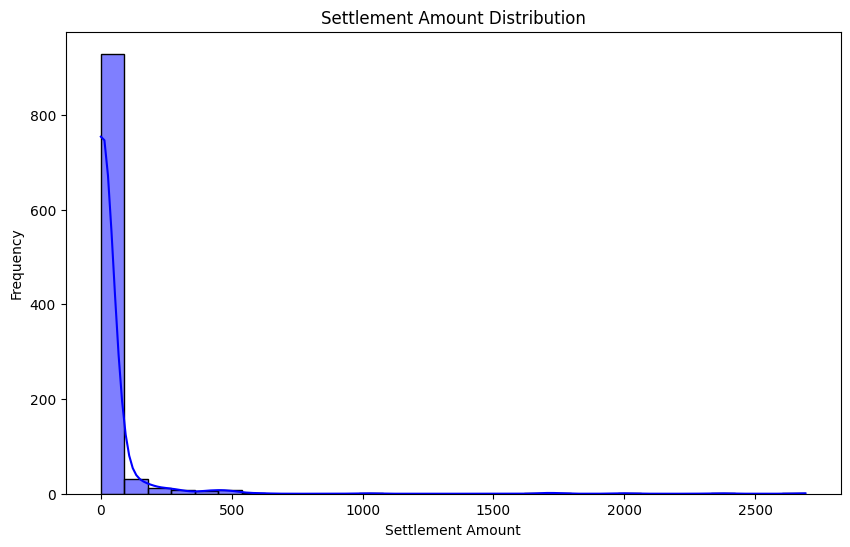

In [11]:
# Settlement Amount Distribution using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df['settlement_amount'], bins=30, kde=True, color='blue')
plt.title('Settlement Amount Distribution')
plt.xlabel('Settlement Amount')
plt.ylabel('Frequency')
plt.show()

Transaction Amount

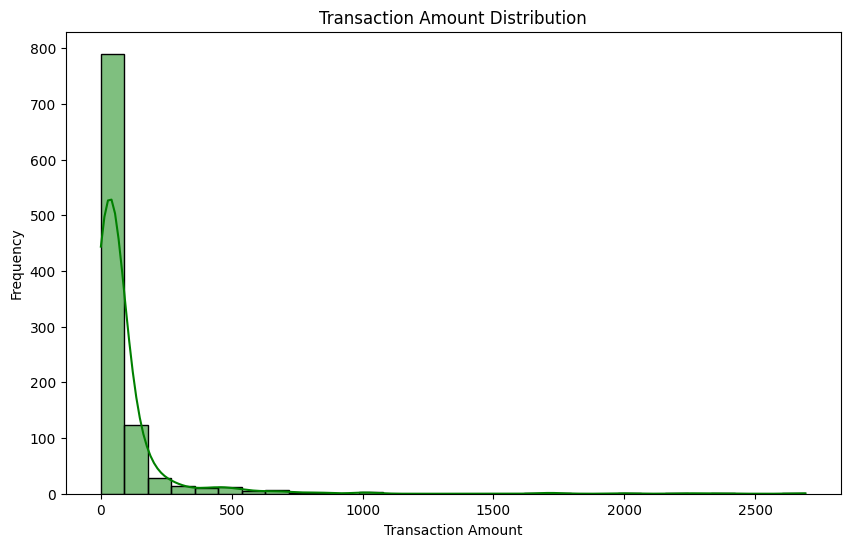

In [12]:
# Transaction Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['transaction_amount'], bins=30, kde=True, color='green')
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

Consumer Status

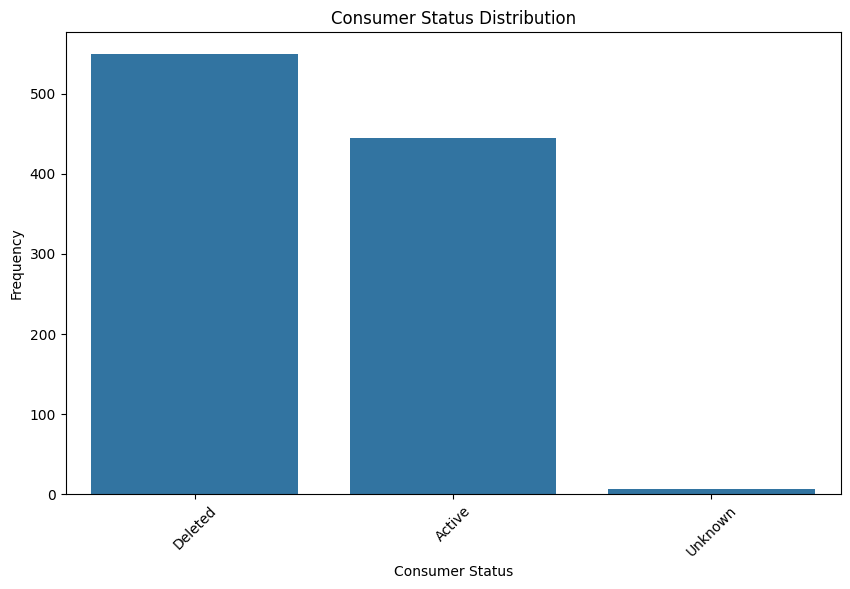

In [13]:
# Consumer Status Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=df['consumer_status'], order=df['consumer_status'].value_counts().index)
plt.title('Consumer Status Distribution')
plt.xlabel('Consumer Status')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

Account Status

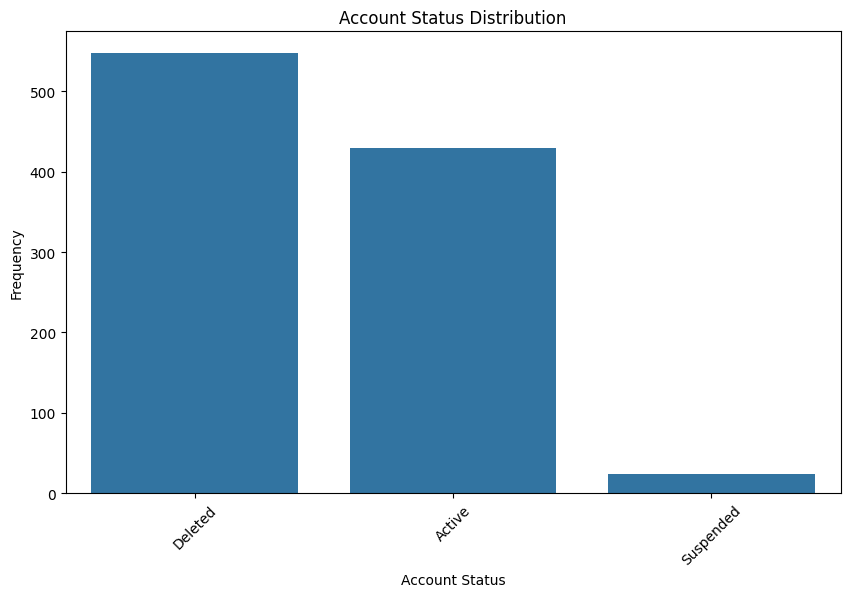

In [14]:
# Account Status Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=df['account_status'], order=df['account_status'].value_counts().index)
plt.title('Account Status Distribution')
plt.xlabel('Account Status')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


Offer Link Status

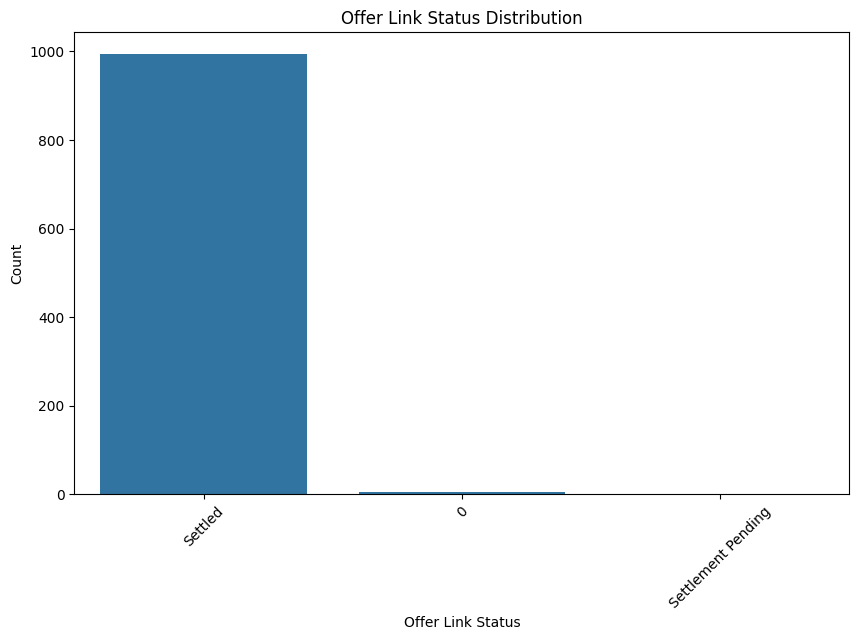

In [15]:
# Offer Link Status Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=df['offer_link_status'], order=df['offer_link_status'].value_counts().index)
plt.title('Offer Link Status Distribution')
plt.xlabel('Offer Link Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Store ID Distribution (Top 20 most frequent)

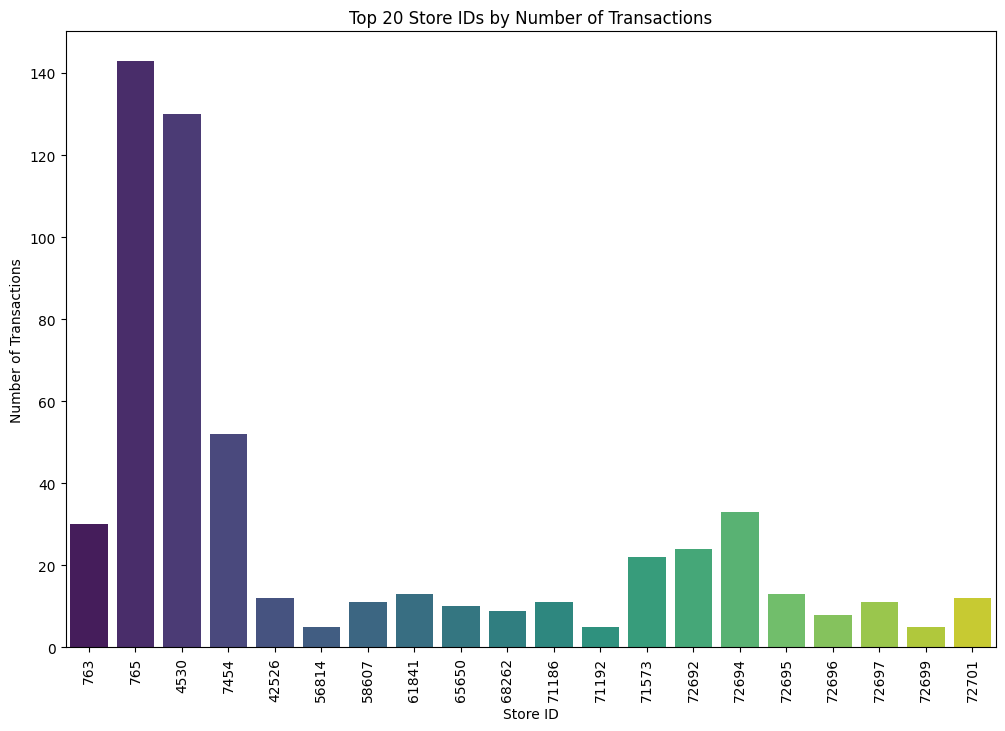

In [16]:
# Store ID Distribution (Top 20 most frequent)
plt.figure(figsize=(12, 8))
store_counts = df['store_id'].value_counts().head(20)
sns.barplot(x=store_counts.index, y=store_counts.values, palette='viridis')
plt.title('Top 20 Store IDs by Number of Transactions')
plt.xlabel('Store ID')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.show()

Boxplot for Settlement Amount

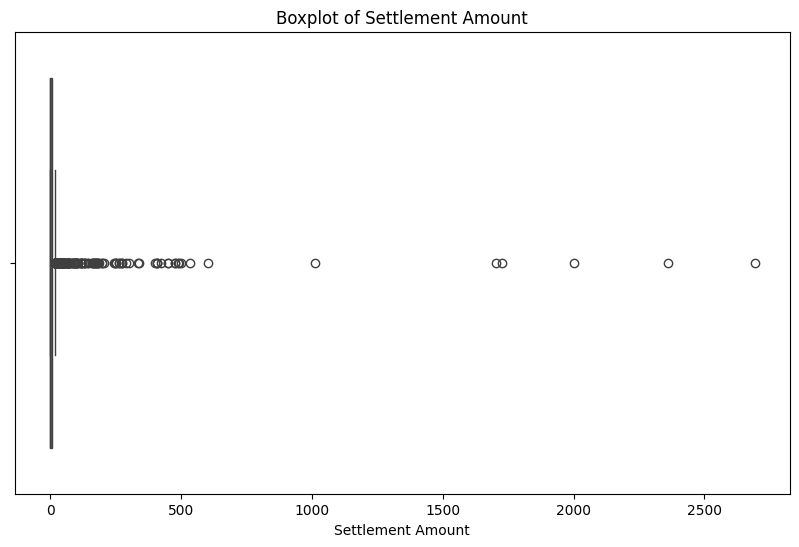

In [17]:
# Boxplot for Settlement Amount
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['settlement_amount'])
plt.title('Boxplot of Settlement Amount')
plt.xlabel('Settlement Amount')
plt.show()

# Smart Pay EDA

In [18]:
df = pd.read_csv("sp_customer.csv")

In [19]:
df.head()

,merchant_id,member_id,member_external_id,member_programme_id,member_tier,member_created_at,member_updated_at,order_id,order_type,order_changed,...,brand_provider_title,product_id,product_status,product_title,product_sku,product_brand,product_display_name,product_provider_identifier,product_voucher_product_type,product_main_category
0,153,2375,504647953,1737,SKYWARDS,2024-02-10 07:26:35.000000,2024-02-10 07:26:35.000000,1661,voucher_products,2024-02-10 07:27:51.000000,...,NaN,13,1.0,tillo - H&M Australia,ti-h-and-m-au,260,H&M Australia,h-and-m-au,VARIABLE,Clothes and Fashion
1,1122,4371,235534386,1737,SKYWARDS,2024-02-27 15:33:23.000000,2024-02-27 15:33:23.000000,3987,voucher_products,2024-03-02 07:29:02.000000,...,NaN,1005,1.0,ygag - Deliveroo,yg-DELAE,1271,Deliveroo,DELAE,VARIABLE,Food and Drink
2,193,6670,400331912,1737,SKYWARDS,2024-03-26 03:13:40.000000,2024-03-26 03:13:40.000000,6343,voucher_products,2024-03-26 03:14:49.000000,...,NaN,872,1.0,incomm - Macy's,in-MCYS-D-2500-00,1575,Macy's,MCYS-D-2500-00,FIXED,Clothes and Fashion
3,153,1637,655430285,1737,SILVER,2024-02-09 16:18:09.000000,2024-02-09 16:18:09.000000,1112,voucher_products,2024-02-09 16:19:34.000000,...,NaN,153,1.0,tillo - Sainsbury's,ti-sainsburys,539,Sainsbury's,sainsburys,VARIABLE,Food and Drink
4,153,2442,731432225,1737,SKYWARDS,2024-02-10 09:32:26.000000,2024-02-10 09:32:26.000000,1707,voucher_products,2024-02-10 09:32:44.000000,...,NaN,27,1.0,tillo - Argos,ti-argos,288,Argos,argos,VARIABLE,Department Stores


In [20]:
df.tail()

,merchant_id,member_id,member_external_id,member_programme_id,member_tier,member_created_at,member_updated_at,order_id,order_type,order_changed,...,brand_provider_title,product_id,product_status,product_title,product_sku,product_brand,product_display_name,product_provider_identifier,product_voucher_product_type,product_main_category
995,153,5692,520281720,1737,SKYWARDS,2024-03-14 10:02:38.000000,2024-03-14 10:02:38.000000,5164,voucher_products,2024-03-14 10:12:44.000000,...,NaN,94,1.0,tillo - Hotels.com,ti-hotels-com,421,Hotels.com,hotels-com,VARIABLE,Travel
996,153,619,626352156,1737,SKYWARDS,2024-02-09 11:27:19.000000,2024-02-09 11:27:19.000000,486,voucher_products,2024-02-09 11:28:32.000000,...,NaN,1394,1.0,ygag - Fabindia,yg-FABIN,1807,Fabindia,FABIN,VARIABLE,Clothes and Fashion
997,193,2603,637233446,1737,SKYWARDS,2024-02-10 20:04:59.000000,2024-02-10 20:04:59.000000,1854,voucher_products,2024-02-10 20:05:31.000000,...,NaN,153,1.0,tillo - Sainsbury's,ti-sainsburys,539,Sainsbury's,sainsburys,VARIABLE,Food and Drink
998,193,6368,659263850,1737,SKYWARDS,2024-03-21 09:59:19.000000,2024-03-21 09:59:19.000000,8197,voucher_products,2024-04-09 07:10:41.000000,...,NaN,1120,1.0,ygag - Noon,yg-NOOAE,1386,Noon,NOOAE,VARIABLE,Department Stores
999,153,7137,251135824,1737,SKYWARDS,2024-03-31 06:56:15.000000,2024-03-31 06:56:15.000000,7190,voucher_products,2024-03-31 07:03:42.000000,...,NaN,1113,1.0,ygag - Nando's,yg-NANAE,1379,Nando's,NANAE,VARIABLE,Food and Drink


In [21]:
df.shape

(1000, 41)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   merchant_id                     1000 non-null   int64  
 1   member_id                       1000 non-null   int64  
 2   member_external_id              1000 non-null   int64  
 3   member_programme_id             1000 non-null   int64  
 4   member_tier                     1000 non-null   object 
 5   member_created_at               1000 non-null   object 
 6   member_updated_at               1000 non-null   object 
 7   order_id                        1000 non-null   int64  
 8   order_type                      1000 non-null   object 
 9   order_changed                   1000 non-null   object 
 10  order_item_status               1000 non-null   object 
 11  order_item_sku                  1000 non-null   object 
 12  order_item_title                100

In [23]:
df.isnull().sum()

merchant_id                          0
member_id                            0
member_external_id                   0
member_programme_id                  0
member_tier                          0
member_created_at                    0
member_updated_at                    0
order_id                             0
order_type                           0
order_changed                        0
order_item_status                    0
order_item_sku                       0
order_item_title                     0
order_item_quantity                  0
order_item_total_points              0
order_item_base_item_price           0
order_item_product_id                0
order_item_brand_id                  0
order_item_changed                   0
order_item_cash_flow_margin          0
order_item_cash_flow_surcharge       0
order_item_client_points             0
order_item_client_sell_price         0
order_item_discount                  0
order_item_merchant_price            0
order_item_provider_ident

In [24]:
# Drop columns with 1000 missing values
columns_to_drop = ['order_item_provider_identifier', 'brand_provider_nid',
                   'brand_provider_status', 'brand_provider_title']
df = df.drop(columns=columns_to_drop)

#replace missing values with the most common value
most_common_product_status = df['product_status'].mode()[0]
df['product_status'].fillna(most_common_product_status, inplace=True)

most_common_main_category = df['product_main_category'].mode()[0]
df['product_main_category'].fillna(most_common_main_category, inplace=True)

df.isnull().sum()

merchant_id                       0
member_id                         0
member_external_id                0
member_programme_id               0
member_tier                       0
member_created_at                 0
member_updated_at                 0
order_id                          0
order_type                        0
order_changed                     0
order_item_status                 0
order_item_sku                    0
order_item_title                  0
order_item_quantity               0
order_item_total_points           0
order_item_base_item_price        0
order_item_product_id             0
order_item_brand_id               0
order_item_changed                0
order_item_cash_flow_margin       0
order_item_cash_flow_surcharge    0
order_item_client_points          0
order_item_client_sell_price      0
order_item_discount               0
order_item_merchant_price         0
order_item_voucher_provider       0
brand_title                       0
brand_provider_identifier   

In [25]:
df.head()

,merchant_id,member_id,member_external_id,member_programme_id,member_tier,member_created_at,member_updated_at,order_id,order_type,order_changed,...,brand_provider_identifier,product_id,product_status,product_title,product_sku,product_brand,product_display_name,product_provider_identifier,product_voucher_product_type,product_main_category
0,153,2375,504647953,1737,SKYWARDS,2024-02-10 07:26:35.000000,2024-02-10 07:26:35.000000,1661,voucher_products,2024-02-10 07:27:51.000000,...,h-and-m-au,13,1.0,tillo - H&M Australia,ti-h-and-m-au,260,H&M Australia,h-and-m-au,VARIABLE,Clothes and Fashion
1,1122,4371,235534386,1737,SKYWARDS,2024-02-27 15:33:23.000000,2024-02-27 15:33:23.000000,3987,voucher_products,2024-03-02 07:29:02.000000,...,DELAE,1005,1.0,ygag - Deliveroo,yg-DELAE,1271,Deliveroo,DELAE,VARIABLE,Food and Drink
2,193,6670,400331912,1737,SKYWARDS,2024-03-26 03:13:40.000000,2024-03-26 03:13:40.000000,6343,voucher_products,2024-03-26 03:14:49.000000,...,MCYS-D-2500-00,872,1.0,incomm - Macy's,in-MCYS-D-2500-00,1575,Macy's,MCYS-D-2500-00,FIXED,Clothes and Fashion
3,153,1637,655430285,1737,SILVER,2024-02-09 16:18:09.000000,2024-02-09 16:18:09.000000,1112,voucher_products,2024-02-09 16:19:34.000000,...,sainsburys,153,1.0,tillo - Sainsbury's,ti-sainsburys,539,Sainsbury's,sainsburys,VARIABLE,Food and Drink
4,153,2442,731432225,1737,SKYWARDS,2024-02-10 09:32:26.000000,2024-02-10 09:32:26.000000,1707,voucher_products,2024-02-10 09:32:44.000000,...,argos,27,1.0,tillo - Argos,ti-argos,288,Argos,argos,VARIABLE,Department Stores


In [26]:
# Descriptive statistics for numerical columns
df.describe()

,merchant_id,member_id,member_external_id,member_programme_id,order_id,order_item_quantity,order_item_total_points,order_item_base_item_price,order_item_product_id,order_item_brand_id,order_item_cash_flow_margin,order_item_cash_flow_surcharge,order_item_client_points,order_item_client_sell_price,order_item_discount,order_item_merchant_price,product_id,product_status,product_brand
count,1000.000000,1000.000000,1.000000e+03,1000.0,1000.000000,1000.0,1000.000000,1000.000000,1000.00000,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.0,1000.000000
mean,302.618000,3868.229000,4.709572e+08,1737.0,3679.601000,1.0,14394.211000,300.937656,463.25000,796.221000,0.0,0.0,13507.444000,313.991860,5.227980,300.937656,463.25000,1.0,796.221000
std,332.112874,2180.141358,2.115703e+08,0.0,2235.844064,0.0,15652.134838,1094.100153,494.51285,516.834087,0.0,0.0,15235.814697,1134.655442,2.299538,1094.100153,494.51285,0.0,516.834087
min,39.000000,9.000000,1.040754e+08,1737.0,103.000000,1.0,2000.000000,6.157000,8.00000,250.000000,0.0,0.0,1089.000000,6.550000,0.000000,6.157000,8.00000,1.0,250.000000
25%,153.000000,1989.750000,2.676509e+08,1737.0,1704.500000,1.0,4612.500000,28.055950,61.00000,356.000000,0.0,0.0,4068.750000,30.000000,3.600000,28.055950,61.00000,1.0,356.000000
50%,193.000000,3793.000000,5.016894e+08,1737.0,3468.500000,1.0,9892.000000,58.200000,153.00000,539.000000,0.0,0.0,9540.000000,62.300000,4.800000,58.200000,153.00000,1.0,539.000000
75%,193.000000,5720.000000,6.754238e+08,1737.0,5487.500000,1.0,17185.000000,134.532600,971.00000,1237.000000,0.0,0.0,15827.750000,143.040000,6.000000,134.532600,971.00000,1.0,1237.000000
max,1122.000000,7834.000000,9.990042e+08,1737.0,8363.000000,1.0,174592.000000,14605.500000,1436.00000,2231.000000,0.0,0.0,174592.000000,15000.000000,14.000000,14605.500000,1436.00000,1.0,2231.000000


Member Tier distribution

Text(0, 0.5, 'Frequency')

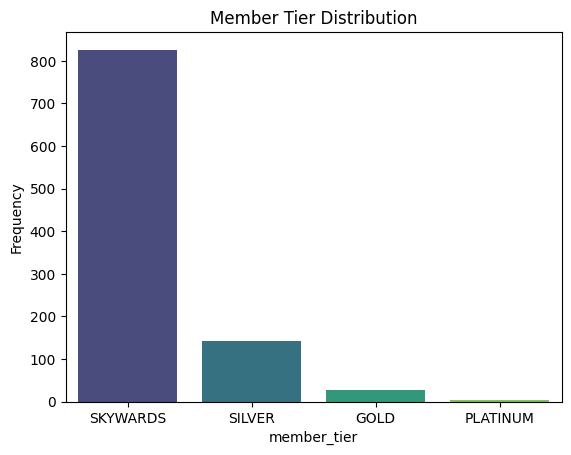

In [27]:
# Member Tier distribution
sns.countplot(data=df, x='member_tier',palette='viridis')
plt.title('Member Tier Distribution')
plt.ylabel('Frequency')



Product Main Category distribution

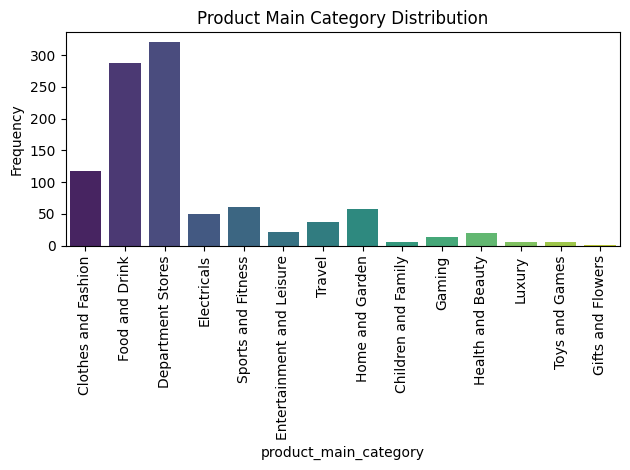

In [28]:
# Product Main Category distribution
sns.countplot(data=df, x='product_main_category',palette='viridis')
plt.title('Product Main Category Distribution')
plt.ylabel('Frequency')
plt.tick_params(axis='x', rotation=90)  # Rotate x-labels for better visibility
plt.tight_layout()
plt.show()


Order Item Total Points

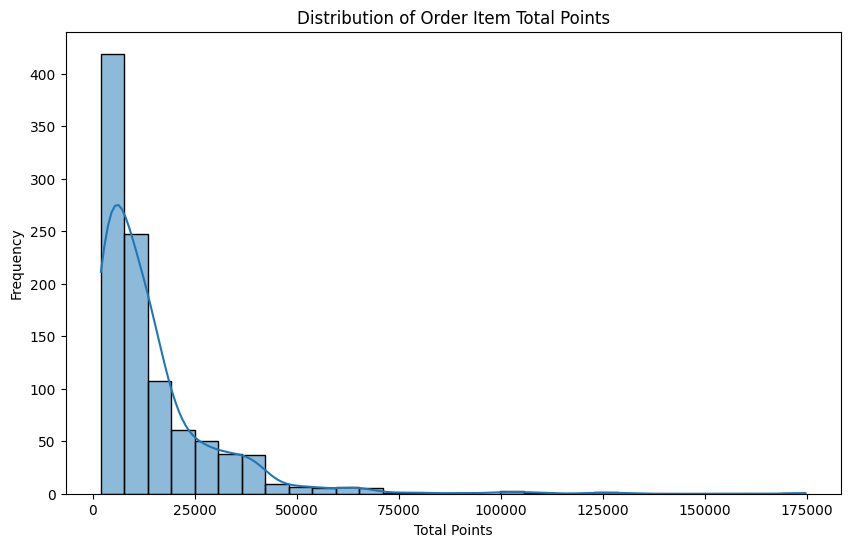

In [29]:

# Order Item Total Points
plt.figure(figsize=(10, 6))
sns.histplot(df['order_item_total_points'], bins=30, kde=True)
plt.title('Distribution of Order Item Total Points')
plt.xlabel('Total Points')
plt.ylabel('Frequency')
plt.show()



Order Item Base Item Price

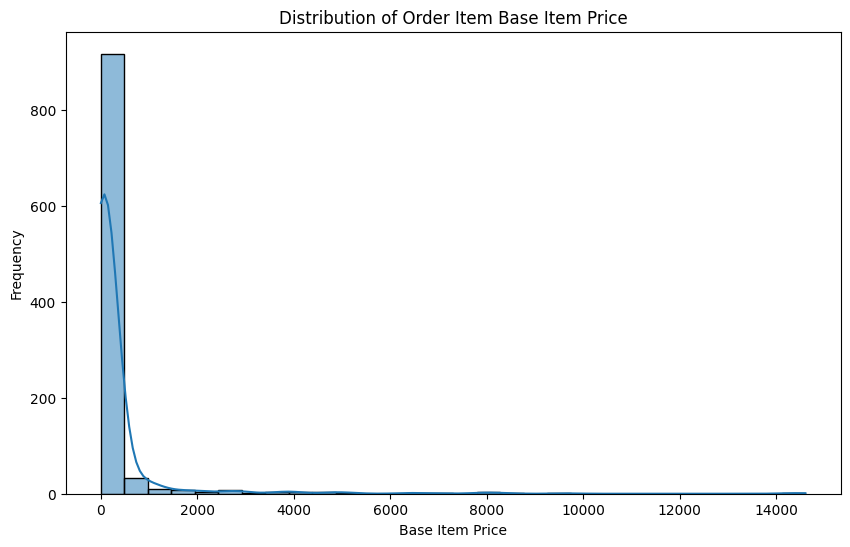

In [30]:
# Order Item Base Item Price
plt.figure(figsize=(10, 6))
sns.histplot(df['order_item_base_item_price'], bins=30, kde=True)
plt.title('Distribution of Order Item Base Item Price')
plt.xlabel('Base Item Price')
plt.ylabel('Frequency')
plt.show()



Order Item Discount

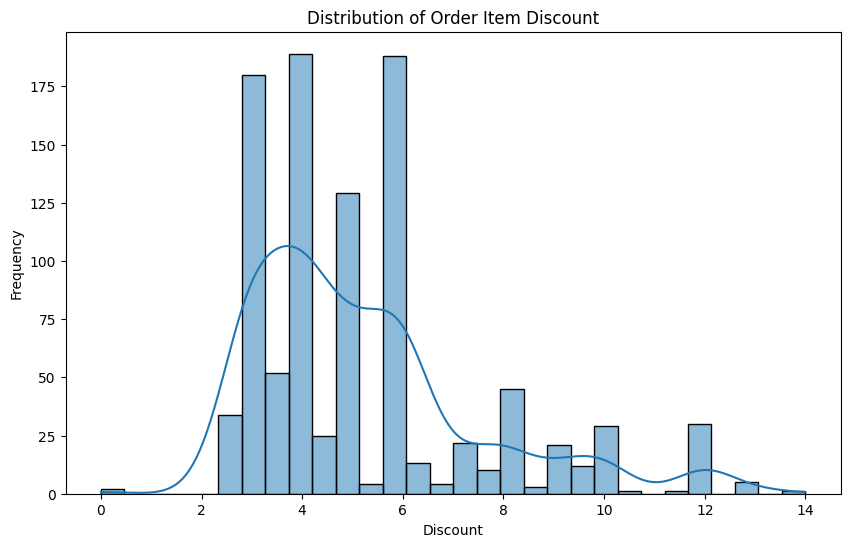

In [31]:
# Order Item Discount
plt.figure(figsize=(10, 6))
sns.histplot(df['order_item_discount'], bins=30, kde=True)
plt.title('Distribution of Order Item Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()



Order Item Merchant Price

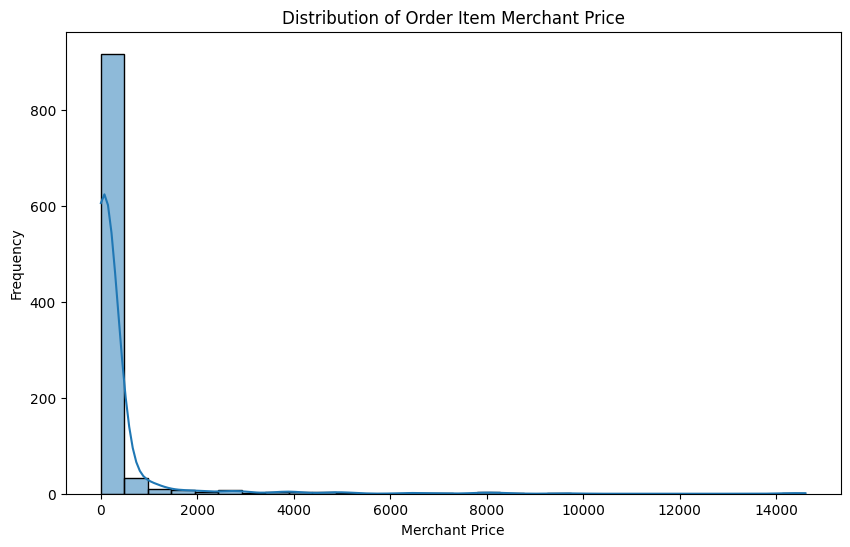

In [32]:
# Order Item Merchant Price
plt.figure(figsize=(10, 6))
sns.histplot(df['order_item_merchant_price'], bins=30, kde=True)
plt.title('Distribution of Order Item Merchant Price')
plt.xlabel('Merchant Price')
plt.ylabel('Frequency')
plt.show()

Creating Box Plot and Violin Plot for **order_item_total_points**

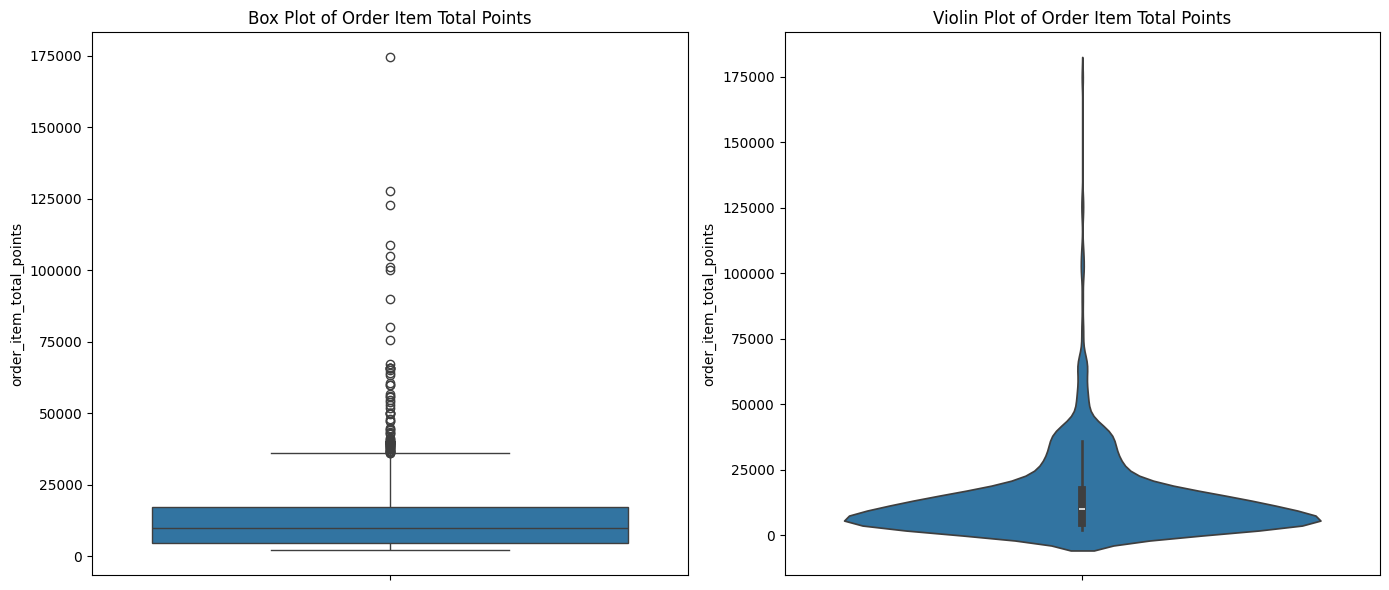

In [33]:
# Creating Box Plot and Violin Plot for 'order_item_total_points'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=df['order_item_total_points'], ax=axes[0])
axes[0].set_title('Box Plot of Order Item Total Points')
sns.violinplot(y=df['order_item_total_points'], ax=axes[1])
axes[1].set_title('Violin Plot of Order Item Total Points')
plt.tight_layout()
plt.show()

# Smart Earn

In [34]:
df = pd.read_csv("se_customer.csv")

In [35]:
df

,membershipid,merchant_id,last_order_date,total_points_earned,total_order_amount_in_currency,total_number_of_orders,last_points_earned,last_order_amount_in_currency,date_last_activity_earn,last_activity_earn,refresheddate,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,1103245683,153,11/04/2017 21:58,642,546.75,1,642,546.75,11/04/2017 21:58,Purchase,15/07/2021,NaN,NaN,NaN
1,2028342815,281,09/05/2014 23:07,539,450.51,1,539,450.51,18/05/2014 19:50,Click,27/06/2023,NaN,NaN,NaN
2,2050937124,1122,08/02/2017 16:17,161,48.00,1,161,48.00,08/02/2017 16:17,Purchase,15/07/2021,NaN,NaN,NaN
3,2112182725,651,24/07/2016 11:40,116,139.70,4,17,18.16,24/07/2016 11:40,Purchase,27/06/2023,NaN,NaN,NaN
4,5016618831,651,02/10/2021 09:10,79,165.83,4,46,97.50,02/10/2021 09:10,Purchase,27/06/2023,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2125887034,193,02/09/2015 20:18,584,138.84,1,584,138.84,02/09/2015 20:18,Purchase,15/07/2021,NaN,NaN,NaN
996,4400706703,193,14/09/2012 08:17,918,398.50,1,918,398.50,14/09/2012 08:17,Purchase,27/06/2023,NaN,NaN,NaN
997,5068048240,39,20/12/2022 16:34,109,33.08,1,109,33.08,20/12/2022 16:34,Purchase,28/12/2023,NaN,NaN,NaN
998,1106715830,193,13/12/2015 11:37,143,34.97,1,143,34.97,13/12/2015 11:37,Purchase,15/07/2021,NaN,NaN,NaN


In [36]:
columns_to_drop = ['Unnamed: 11', 'Unnamed: 12','Unnamed: 13']
df = df.drop(columns=columns_to_drop)

In [37]:
df.shape

(1000, 11)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   membershipid                    1000 non-null   int64  
 1   merchant_id                     1000 non-null   int64  
 2   last_order_date                 1000 non-null   object 
 3   total_points_earned             1000 non-null   int64  
 4   total_order_amount_in_currency  1000 non-null   float64
 5   total_number_of_orders          1000 non-null   int64  
 6   last_points_earned              1000 non-null   int64  
 7   last_order_amount_in_currency   1000 non-null   float64
 8   date_last_activity_earn         1000 non-null   object 
 9   last_activity_earn              1000 non-null   object 
 10  refresheddate                   1000 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 86.1+ KB


In [39]:
df.describe()

,membershipid,merchant_id,total_points_earned,total_order_amount_in_currency,total_number_of_orders,last_points_earned,last_order_amount_in_currency
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.141314e+09,302.618000,4002.414000,1658.647220,1.269000,2112.265000,861.827500
std,1.923720e+09,332.112874,16909.906377,6769.837873,0.644247,8264.488323,3234.264189
min,1.103246e+09,39.000000,7.000000,14.170000,1.000000,7.000000,14.170000
25%,2.050783e+09,153.000000,143.000000,34.970000,1.000000,109.000000,34.970000
50%,2.125887e+09,193.000000,245.000000,138.840000,1.000000,243.000000,135.255000
75%,5.068048e+09,193.000000,644.000000,398.500000,1.000000,584.000000,398.500000
max,8.835980e+09,1122.000000,85696.000000,34349.000000,6.000000,42006.000000,16464.000000


In [40]:
df.isnull().sum()

membershipid                      0
merchant_id                       0
last_order_date                   0
total_points_earned               0
total_order_amount_in_currency    0
total_number_of_orders            0
last_points_earned                0
last_order_amount_in_currency     0
date_last_activity_earn           0
last_activity_earn                0
refresheddate                     0
dtype: int64

In [41]:
df

,membershipid,merchant_id,last_order_date,total_points_earned,total_order_amount_in_currency,total_number_of_orders,last_points_earned,last_order_amount_in_currency,date_last_activity_earn,last_activity_earn,refresheddate
0,1103245683,153,11/04/2017 21:58,642,546.75,1,642,546.75,11/04/2017 21:58,Purchase,15/07/2021
1,2028342815,281,09/05/2014 23:07,539,450.51,1,539,450.51,18/05/2014 19:50,Click,27/06/2023
2,2050937124,1122,08/02/2017 16:17,161,48.00,1,161,48.00,08/02/2017 16:17,Purchase,15/07/2021
3,2112182725,651,24/07/2016 11:40,116,139.70,4,17,18.16,24/07/2016 11:40,Purchase,27/06/2023
4,5016618831,651,02/10/2021 09:10,79,165.83,4,46,97.50,02/10/2021 09:10,Purchase,27/06/2023
...,...,...,...,...,...,...,...,...,...,...,...
995,2125887034,193,02/09/2015 20:18,584,138.84,1,584,138.84,02/09/2015 20:18,Purchase,15/07/2021
996,4400706703,193,14/09/2012 08:17,918,398.50,1,918,398.50,14/09/2012 08:17,Purchase,27/06/2023
997,5068048240,39,20/12/2022 16:34,109,33.08,1,109,33.08,20/12/2022 16:34,Purchase,28/12/2023
998,1106715830,193,13/12/2015 11:37,143,34.97,1,143,34.97,13/12/2015 11:37,Purchase,15/07/2021


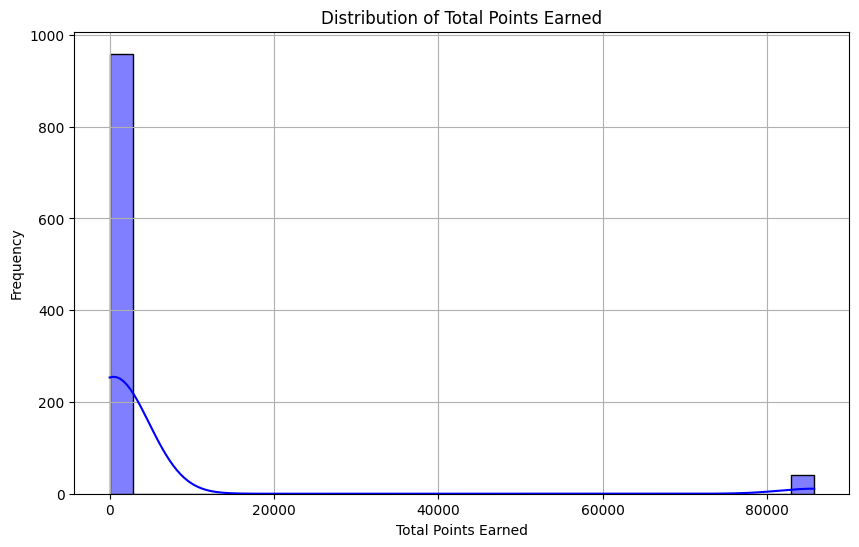

In [42]:
# Histogram of total points earned
plt.figure(figsize=(10, 6))
sns.histplot(df['total_points_earned'], bins=30, kde=True, color='blue')
plt.title('Distribution of Total Points Earned')
plt.xlabel('Total Points Earned')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


Total order amount

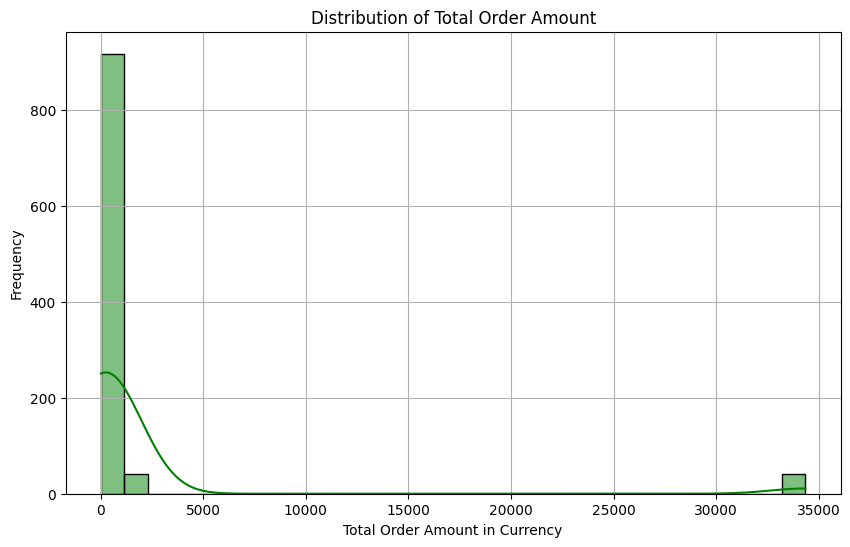

In [43]:
# Histogram of total order amount
plt.figure(figsize=(10, 6))
sns.histplot(df['total_order_amount_in_currency'], bins=30, kde=True, color='green')
plt.title('Distribution of Total Order Amount')
plt.xlabel('Total Order Amount in Currency')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


last activity types

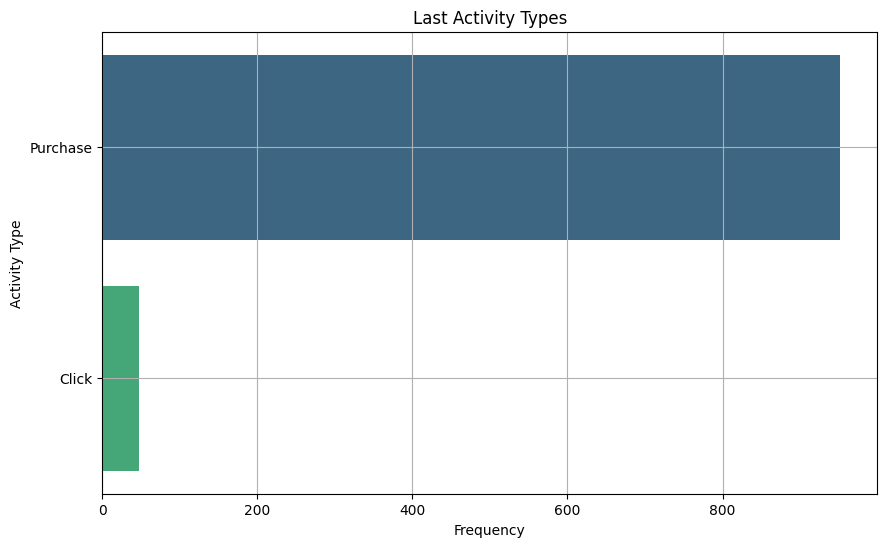

In [44]:
# Bar plot of last activity types
plt.figure(figsize=(10, 6))
sns.countplot(y='last_activity_earn', data=df, order=df['last_activity_earn'].value_counts().index, palette='viridis')
plt.title('Last Activity Types')
plt.xlabel('Frequency')
plt.ylabel('Activity Type')
plt.grid(True)
plt.show()


Time Series Plot of total order amount over time

In [ ]:
# # Time Series Plot of total order amount over time
# plt.figure(figsize=(14, 7))
# df.sort_values('last_order_date', inplace=True)
# sns.lineplot(x='last_order_date', y='total_order_amount_in_currency', data=df, marker='o', color='cyan')
# plt.title('Time Series of Total Order Amount over Time')
# plt.xlabel('Last Order Date')
# plt.ylabel('Total Order Amount in Currency')
# plt.grid(True)
# plt.show()

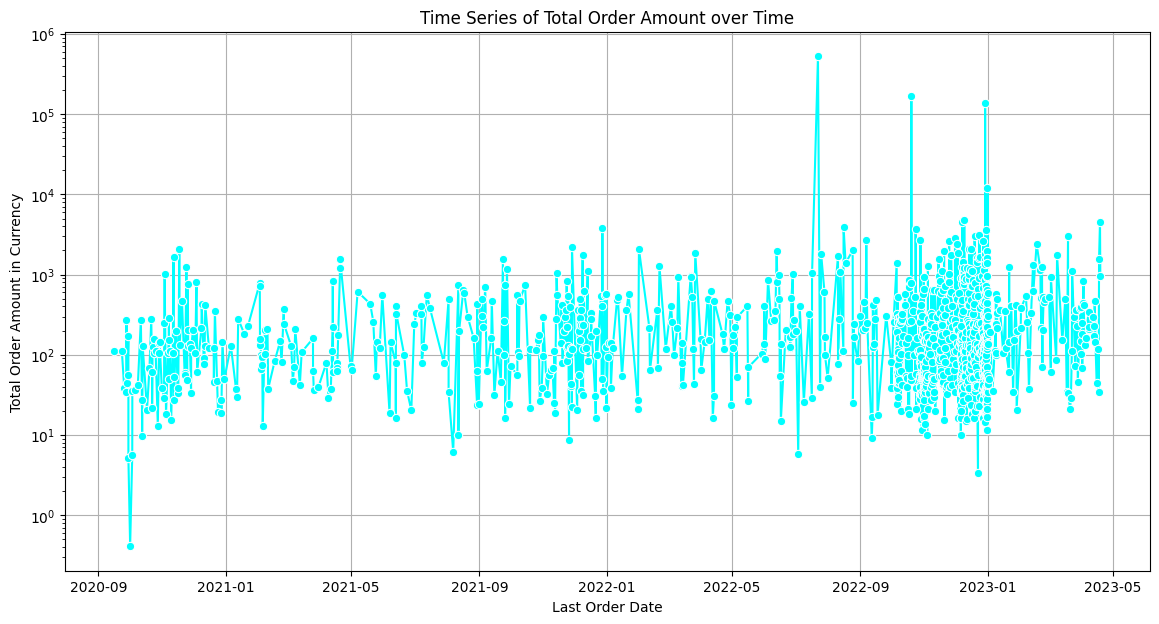

In [61]:
# Sorting the DataFrame by date just in case
df.sort_values('last_order_date', inplace=True)

plt.figure(figsize=(14, 7))
sns.lineplot(x='last_order_date', y='total_order_amount_in_currency', data=df, marker='o', color='cyan')
plt.title('Time Series of Total Order Amount over Time')
plt.xlabel('Last Order Date')
plt.ylabel('Total Order Amount in Currency')
plt.yscale('log')
plt.grid(True)
plt.show()

Violin plots for total order amount and total points earned

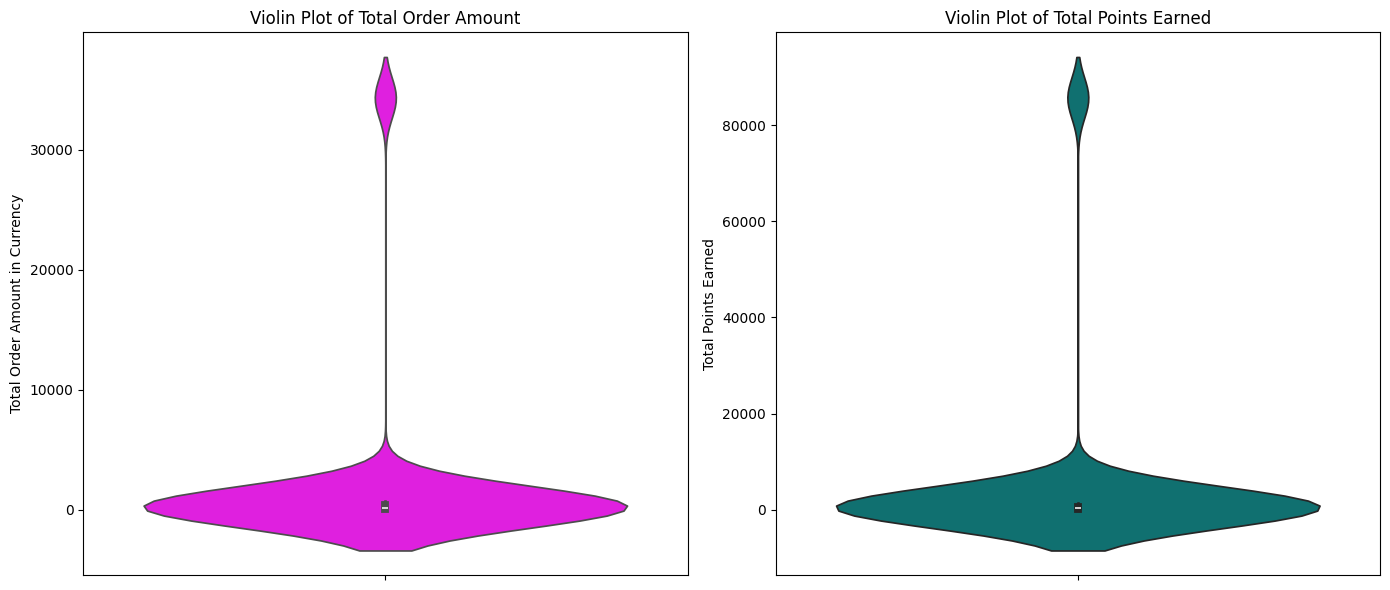

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Total Order Amount in Currency
sns.violinplot(y=df['total_order_amount_in_currency'], ax=ax[0], color='magenta')
ax[0].set_title('Violin Plot of Total Order Amount')
ax[0].set_ylabel('Total Order Amount in Currency')

# Total Points Earned
sns.violinplot(y=df['total_points_earned'], ax=ax[1], color='teal')
ax[1].set_title('Violin Plot of Total Points Earned')
ax[1].set_ylabel('Total Points Earned')

plt.tight_layout()
plt.show()


**last_activity_earn** vs **membershipid**

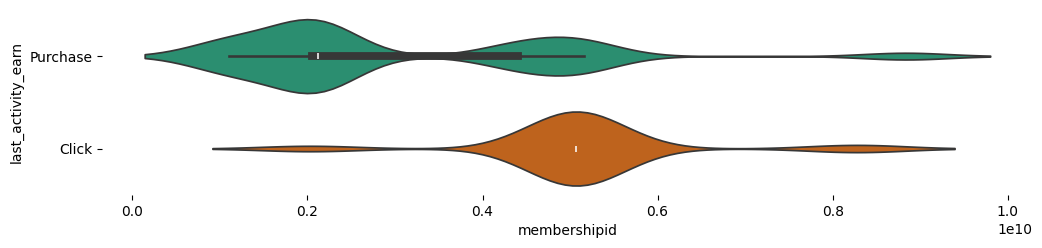

In [47]:
#violin plot last_activity_earn vs membershipid

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['last_activity_earn'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='membershipid', y='last_activity_earn', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

# Smart Redeem Store

In [48]:
df = pd.read_csv('srs_customer.csv')

In [49]:
df

,merchant_id,membershipid,last_order_date,total_order_amount_in_points,total_order_amount_in_currency,last_order_value_in_points,last_order_value_in_currency,total_number_of_orders
0,153,1143419335,2021-09-30 19:41:56.000000,36490.0,72.980000,5215.0,10.430000,1
1,1122,1022135051,2022-11-26 20:19:33.000000,237230.0,615.040741,19799.0,51.330741,1
2,193,2072966032,2022-12-31 17:56:58.000000,21564.0,48.986000,10782.0,24.493000,1
3,153,2010642615,2022-03-31 19:35:59.000000,58600.0,158.220000,9700.0,26.190000,2
4,153,5099625391,2022-10-19 09:33:08.000000,82436.0,260.589000,41218.0,130.294500,1
...,...,...,...,...,...,...,...,...
995,153,8542670554,2020-11-20 00:10:08.000000,174240.0,470.448000,23152.0,51.229800,1
996,153,1117921986,2022-12-13 17:09:37.000000,11068.0,38.738000,5534.0,19.369000,1
997,193,1131568070,2023-02-16 18:40:17.000000,685675.0,2399.862500,0.0,0.000000,9
998,193,1178132851,2022-09-12 19:57:58.000000,47644.0,123.521481,19799.0,51.330741,1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   merchant_id                     1000 non-null   int64  
 1   membershipid                    1000 non-null   int64  
 2   last_order_date                 1000 non-null   object 
 3   total_order_amount_in_points    1000 non-null   float64
 4   total_order_amount_in_currency  1000 non-null   float64
 5   last_order_value_in_points      1000 non-null   float64
 6   last_order_value_in_currency    1000 non-null   float64
 7   total_number_of_orders          1000 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


In [51]:
df.shape

(1000, 8)

In [52]:
df.describe()

,merchant_id,membershipid,total_order_amount_in_points,total_order_amount_in_currency,last_order_value_in_points,last_order_value_in_currency,total_number_of_orders
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,302.618000,2.396954e+09,1.147378e+05,1172.102748,27578.478000,80.583868,1.699000
std,332.112874,1.858631e+09,1.866838e+05,18054.547227,44148.832903,140.798960,1.908413
min,39.000000,1.000583e+09,1.520000e+02,0.410400,0.000000,0.000000,1.000000
25%,153.000000,1.182836e+09,2.043950e+04,52.770400,6709.500000,17.418625,1.000000
50%,193.000000,2.024825e+09,4.973500e+04,132.135500,13988.000000,35.948500,1.000000
75%,193.000000,2.103581e+09,1.209185e+05,340.744383,28454.750000,79.910550,2.000000
max,1122.000000,8.989142e+09,2.122584e+06,527832.654000,430745.000000,1493.688000,21.000000


In [53]:
df.isnull().sum()

merchant_id                       0
membershipid                      0
last_order_date                   0
total_order_amount_in_points      0
total_order_amount_in_currency    0
last_order_value_in_points        0
last_order_value_in_currency      0
total_number_of_orders            0
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   merchant_id                     1000 non-null   int64  
 1   membershipid                    1000 non-null   int64  
 2   last_order_date                 1000 non-null   object 
 3   total_order_amount_in_points    1000 non-null   float64
 4   total_order_amount_in_currency  1000 non-null   float64
 5   last_order_value_in_points      1000 non-null   float64
 6   last_order_value_in_currency    1000 non-null   float64
 7   total_number_of_orders          1000 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


In [55]:
df['last_order_date'] = pd.to_datetime(df['last_order_date'])

total_order_amount_in_points

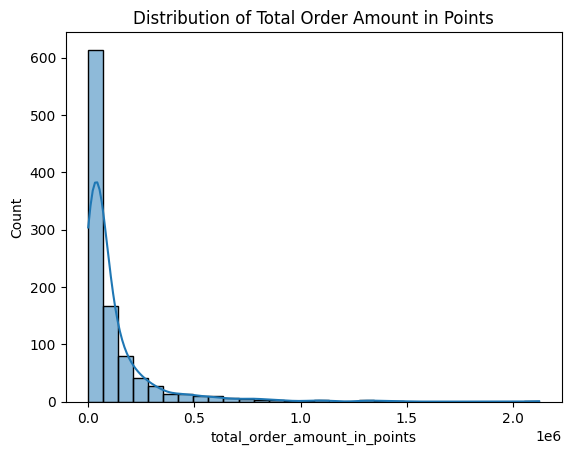

In [56]:
sns.histplot(df['total_order_amount_in_points'], bins=30, kde=True)
plt.title('Distribution of Total Order Amount in Points')
plt.show()

Boxplot total_order_amount_in_points

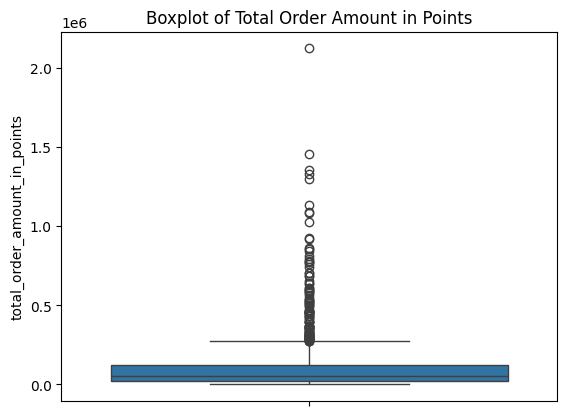

In [57]:
sns.boxplot(data=df, y='total_order_amount_in_points')
plt.title('Boxplot of Total Order Amount in Points')
plt.show()

total_order_amount_in_points v last_order_value_in_points

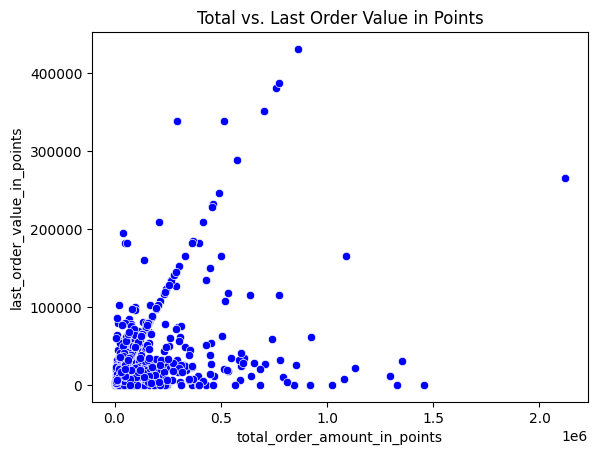

In [58]:
sns.scatterplot(data=df, x='total_order_amount_in_points', y='last_order_value_in_points', color='blue')
plt.title('Total vs. Last Order Value in Points')
plt.show()

orders_per_merchant

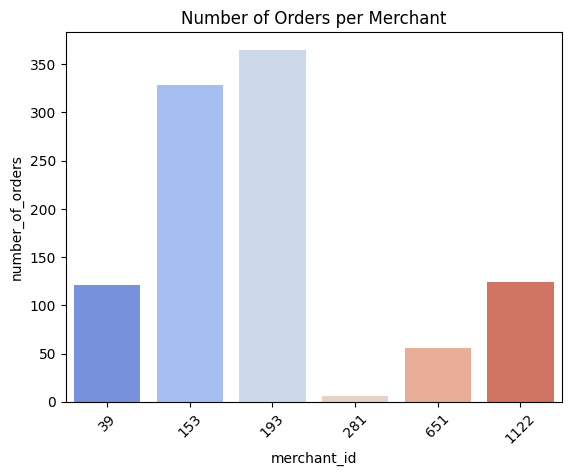

In [59]:
orders_per_merchant = df['merchant_id'].value_counts().reset_index()
orders_per_merchant.columns = ['merchant_id', 'number_of_orders']
sns.barplot(data=orders_per_merchant, x='merchant_id', y='number_of_orders', palette='coolwarm')
plt.title('Number of Orders per Merchant')
plt.xticks(rotation=45)
plt.show()

Orders over Time

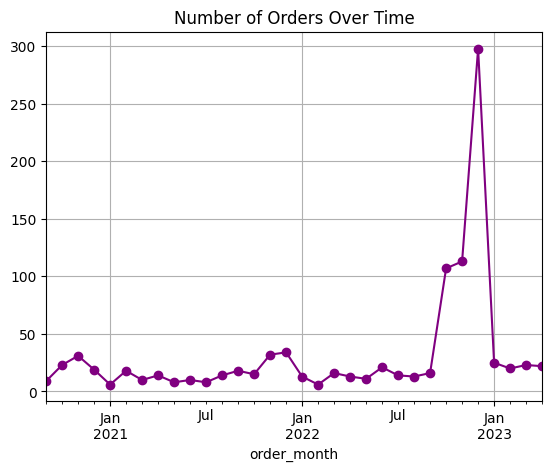

In [60]:
df['order_month'] = df['last_order_date'].dt.to_period('M')
orders_per_month = df.groupby('order_month').size()
orders_per_month.plot(kind='line', marker='o', color='purple')
plt.title('Number of Orders Over Time')
plt.grid(True)
plt.show()